In [33]:
from moviepy import VideoFileClip
import os
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
folders = {
    "Push-Up": "../Dataset/Push-Up",
    "Lunges":  "../Dataset/Lunges",
    "Sit-Up":  "../Dataset/Sit-Up",
    "Pull-Up": "../Dataset/Pull-Up"
}

video_exts = (".mp4")

def get_duration_and_fps(folder_path):
    total_duration = 0.0
    fps_list = []
    
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(video_exts):
            file_path = os.path.join(folder_path, filename)
            try:
                clip = VideoFileClip(file_path)
                
                # durasi
                total_duration += clip.duration
                
                # fps
                if clip.fps:
                    fps_list.append(clip.fps)
                
                clip.close()
            except Exception as e:
                print(f"Gagal baca {filename}: {e}")
    
    avg_fps = sum(fps_list) / len(fps_list) if fps_list else 0
    return total_duration, avg_fps


durations = {}
avg_fps_category = {}
grand_total = 0.0

for label, folder in folders.items():
    if not os.path.exists(folder):
        print(f"Folder tidak ditemukan: {folder}")
        durations[label] = 0.0
        avg_fps_category[label] = 0.0
        continue

    dur, avg_fps = get_duration_and_fps(folder)
    durations[label] = dur
    avg_fps_category[label] = avg_fps
    grand_total += dur

print("Total durasi per kategori:")
for label, dur in durations.items():
    print(f"- {label}: {dur:.2f} detik")

print("\nRata-rata FPS per kategori:")
for label, fps in avg_fps_category.items():
    print(f"- {label}: {fps:.2f} FPS")

print(f"\nTotal durasi semua kategori: {grand_total:.2f} detik")

Total durasi per kategori:
- Push-Up: 83.84 detik
- Lunges: 136.70 detik
- Sit-Up: 134.05 detik
- Pull-Up: 155.07 detik

Rata-rata FPS per kategori:
- Push-Up: 28.30 FPS
- Lunges: 27.25 FPS
- Sit-Up: 27.82 FPS
- Pull-Up: 27.21 FPS

Total durasi semua kategori: 509.66 detik


In [3]:
data_mean = np.load("./Final_Model/zscore_mean.npy")
data_std = np.load("./Final_Model/zscore_std.npy")

print(f'Mean Z-Score: {data_mean}\n')
print(f'Std Z-Score: {data_std}')

Mean Z-Score: [ 72.36067238 110.54638938 148.87169461 137.80536088 124.20967515
 123.16264559  69.22332841 114.0386676  150.23696356 137.31896618
 124.4847561  122.65250658  50.37258188]

Std Z-Score: [55.85046548 51.28964088 26.9142287  49.36220099 53.51187881 27.37081568
 56.11798434 50.29099336 25.06907402 49.27042625 52.2586369  26.43981303
 38.88927595]


In [41]:
# Load data
X_train = np.load("./result/Torso_Angles/Febriansyah/X_train.npy")
X_test  = np.load("./result/Torso_Angles/Febriansyah/X_test.npy")
X_val   = np.load("./result/Torso_Angles/Febriansyah/X_val.npy")

# Gabungkan
X_all = np.concatenate([X_train, X_val, X_test], axis=0)

print("Shape data train:", X_train.shape)
print("Shape data val:", X_val.shape)
print("Shape data test:", X_test.shape)

print("Shape data gabungan:", X_all.shape)

Shape data train: (950, 30, 13)
Shape data val: (132, 30, 13)
Shape data test: (179, 30, 13)
Shape data gabungan: (1261, 30, 13)


In [43]:
# (N, T, F) → (N*T, F)
X_flat = X_all.reshape(-1, X_all.shape[-1])

# Buat DataFrame
angle_columns = [f"Angle_{i+1}" for i in range(X_flat.shape[1])]
Angles_df = pd.DataFrame(X_flat, columns=angle_columns)

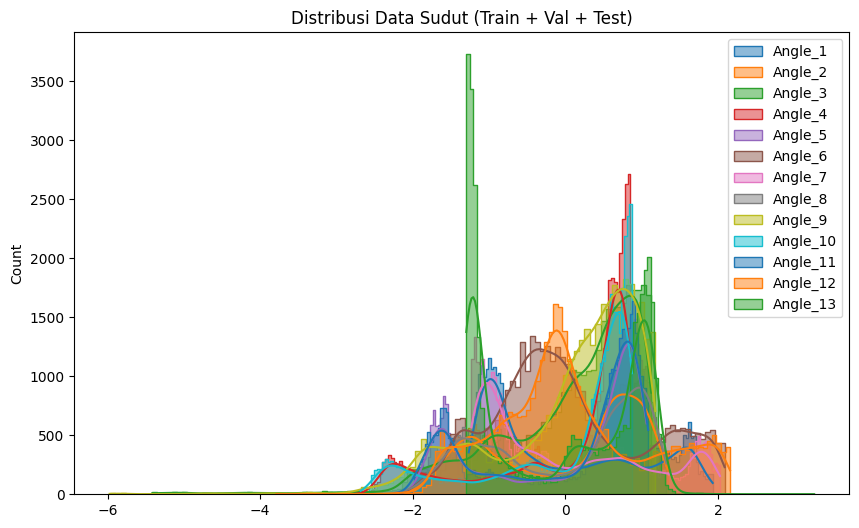

In [50]:
plt.figure(figsize=(10, 6))

for col in Angles_df.columns:
    sns.histplot(
        Angles_df[col],
        kde=True,
        label=col,
        bins=100,
        element="step"
    )

plt.title("Distribusi Data Sudut (Train + Val + Test)")
plt.xlabel(None)
plt.legend()
plt.show()

In [61]:
scenario_path = "./Result/Learning_Rate_1e5"

all_histories = []

for subject in os.listdir(scenario_path):
    subject_path = os.path.join(scenario_path, subject)
    history_file = os.path.join(subject_path, "history.csv")

    if os.path.isfile(history_file):
        df = pd.read_csv(history_file)
        df["subject"] = subject
        all_histories.append(df)

# Gabungkan semua subjek
history_df = pd.concat(all_histories, ignore_index=True)

In [54]:
def plot_learning_curve(df, metric, title, ylabel):
    plt.figure(figsize=(10, 6))

    for subject in df["subject"].unique():
        sub_df = df[df["subject"] == subject]
        plt.plot(sub_df["epoch"], sub_df[metric], label=subject)

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

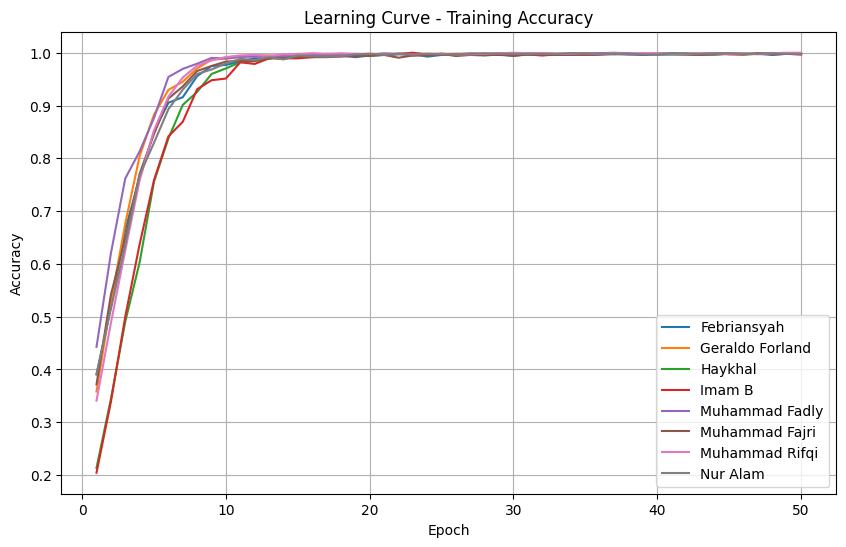

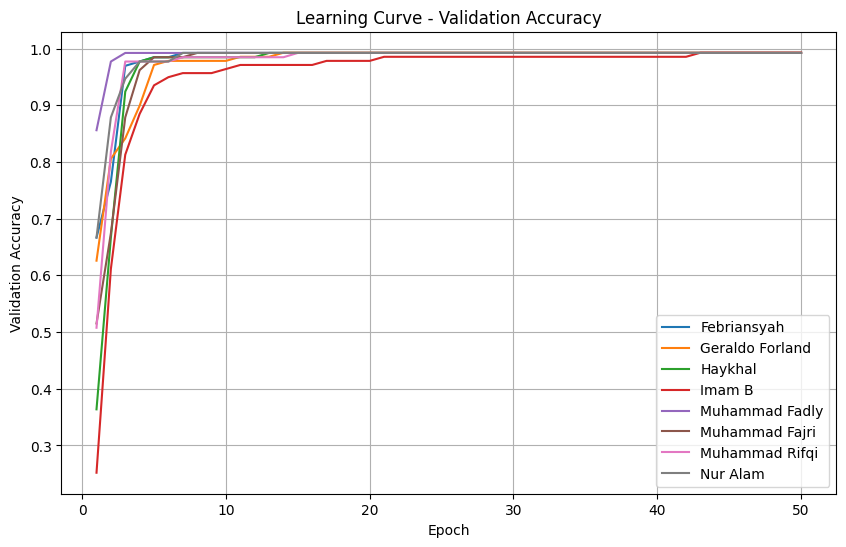

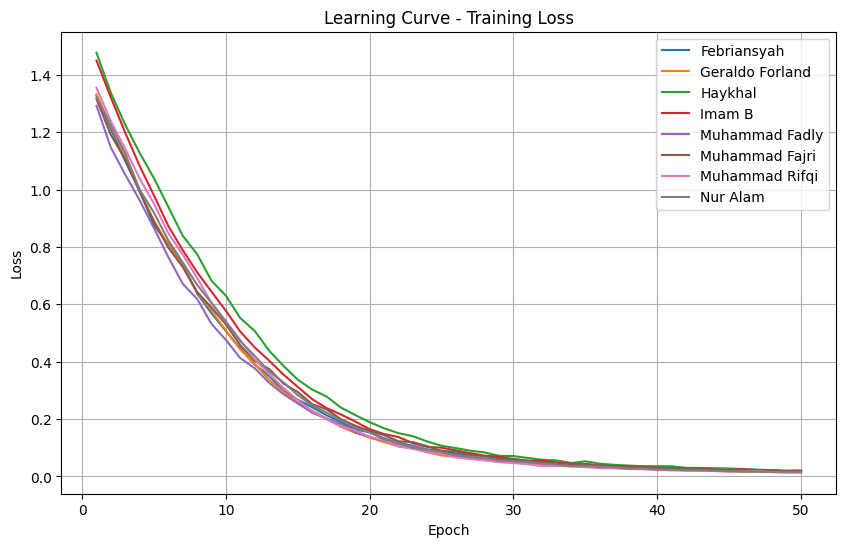

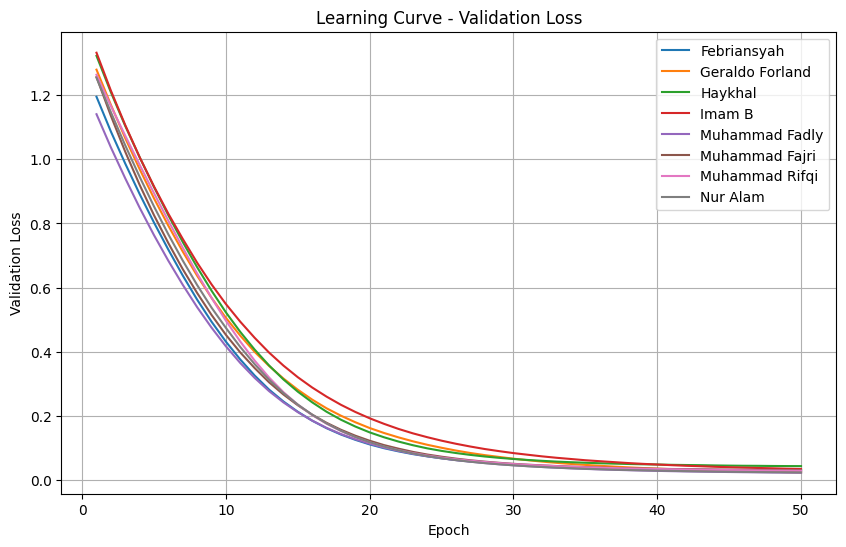

In [62]:
# Training Accuracy
plot_learning_curve(
    history_df,
    metric="accuracy",
    title="Learning Curve - Training Accuracy",
    ylabel="Accuracy"
)

# Validation Accuracy
plot_learning_curve(
    history_df,
    metric="val_accuracy",
    title="Learning Curve - Validation Accuracy",
    ylabel="Validation Accuracy"
)

# Training Loss
plot_learning_curve(
    history_df,
    metric="loss",
    title="Learning Curve - Training Loss",
    ylabel="Loss"
)

# Validation Loss
plot_learning_curve(
    history_df,
    metric="val_loss",
    title="Learning Curve - Validation Loss",
    ylabel="Validation Loss"
)
